In [1]:
import networkx as nx
import numpy as np
from scipy.io import mmread
import pandas as pd
import matplotlib.cm as cmx
import matplotlib.colors as colors

from sklearn import metrics
import matplotlib.pyplot as plt
import copy
import scipy.sparse as sp
import scanpy as sc
import os
import anndata as ad
# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [2]:
gene_TCR = ad.read_h5ad('./10Xdatasets/gex_merge_log1_5000_genes_all_peptides.h5ad')
gene_TCR.obs['used_ix'] = range(gene_TCR.shape[0])
donor_1 = gene_TCR[gene_TCR.obs.donor == 'donor1']
donor_1

/home/phile/miniconda3/envs/integration/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


View of AnnData object with n_obs × n_vars = 35515 × 5000
    obs: 'v_gene_TRA', 'v_gene_TRB', 'd_gene_TRA', 'd_gene_TRB', 'j_gene_TRA', 'j_gene_TRB', 'c_gene_TRA', 'c_gene_TRB', 'cdr3_TRA', 'cdr3_TRB', 'cdr3_nt_TRA', 'cdr3_nt_TRB', 'umis_TRA', 'umis_TRB', 'donor', 'cell_clono_cdr3_aa', 'cell_clono_cdr3_nt', 'CD3', 'CD19', 'CD45RA', 'CD4', 'CD8a', 'CD14', 'CD45RO', 'CD279_PD-1', 'IgG1', 'IgG2a', 'IgG2b', 'CD127', 'CD197_CCR7', 'HLA-DR', 'A0101_VTEHDTLLY_IE-1_CMV', 'A0201_KTWGQYWQV_gp100_Cancer', 'A0201_ELAGIGILTV_MART-1_Cancer', 'A0201_CLLWSFQTSA_Tyrosinase_Cancer', 'A0201_IMDQVPFSV_gp100_Cancer', 'A0201_SLLMWITQV_NY-ESO-1_Cancer', 'A0201_KVAELVHFL_MAGE-A3_Cancer', 'A0201_KVLEYVIKV_MAGE-A1_Cancer', 'A0201_CLLGTYTQDV_Kanamycin-B-dioxygenase', 'A0201_LLDFVRFMGV_EBNA-3B_EBV', 'A0201_LLMGTLGIVC_HPV-16E7_82-91', 'A0201_CLGGLLTMV_LMP-2A_EBV', 'A0201_YLLEMLWRL_LMP1_EBV', 'A0201_FLYALALLL_LMP2A_EBV', 'A0201_GILGFVFTL_Flu-MP_Influenza', 'A0201_GLCTLVAML_BMLF1_EBV', 'A0201_NLVPMVATV_pp65_CMV', '

In [3]:
data_10X_dat = donor_1.obs
data_10X_dat

,v_gene_TRA,v_gene_TRB,d_gene_TRA,d_gene_TRB,j_gene_TRA,j_gene_TRB,c_gene_TRA,c_gene_TRB,cdr3_TRA,cdr3_TRB,...,B0702_GPAESAAGL_NC,NR(B0801)_AAKGRGAAL_NC,antigen,peptide,orig_ix,n_counts,log_counts,n_genes,mt_fraction,used_ix
barcode,,,,,,,,,,,,,,,,,,,,,
AGGGTGAGTATTACCG-18,TRAV19,TRBV20-1,None,TRBD2,TRAJ40,TRBJ2-3,TRAC,TRBC2,CALSEASGTYKYIF,CSAPSGEGRDTQYF,...,0.0,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,0,5478.0,3.738622,1830,0.058050,0
CTTGGCTTCGTTGCCT-25,TRAV23DV6,TRBV7-2,None,TRBD1,TRAJ48,TRBJ2-5,TRAC,TRBC2,CAAILFGNEKLTF,CASSLFDSQETQYF,...,0.0,0.0,unknown,nan,1,4585.0,3.661339,1382,0.063250,1
ACGATACTCGCAGGCT-40,TRAV9-2,TRBV7-6,None,TRBD2,TRAJ49,TRBJ2-3,TRAC,TRBC2,CALSADTGNQFYF,CASSLFDSGRLDTQYF,...,0.0,0.0,unknown,nan,2,3742.0,3.573104,1279,0.067611,2
ACGCCAGTCATGTCTT-8,TRAV12-3,TRBV20-1,None,TRBD1,TRAJ32,TRBJ2-7,TRAC,TRBC2,CAMNPAWGGATNKLIF,CSASPGDYEQYF,...,0.0,0.0,unknown,nan,4,4368.0,3.640283,1669,0.054716,3
TTCTTAGCAAAGAATC-4,TRAV13-2,TRBV4-1,None,TRBD2,TRAJ37,TRBJ2-1,TRAC,TRBC2,CAETALGNTGKLIF,CASSHGKGGNEQFF,...,0.0,0.0,unknown,nan,5,9129.0,3.960423,2683,0.044035,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GTGAAGGGTACCGTAT-36,TRAV12-3,TRBV20-1,None,TRBD1,TRAJ32,TRBJ2-7,TRAC,TRBC2,CAMNPAWGGATNKLIF,CSASPGDYEQYF,...,0.0,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,39691,2345.0,3.370143,1146,0.121109,35510
CTTACCGCAATCAGAA-15,TRAV4,TRBV7-8,None,TRBD2,TRAJ45,TRBJ2-2,TRAC,TRBC2,CLVGEPGGGADGLTF,CASSIGLAGARELFF,...,0.0,0.0,unknown,nan,39693,3728.0,3.571476,1326,0.107564,35511
CGACTTCGTAAGTTCC-24,TRAV36DV7,TRBV2,None,TRBD2,TRAJ42,TRBJ1-1,TRAC,TRBC1,CAVESQGNLIF,CASAGNTEAFF,...,0.0,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,39694,5300.0,3.724276,1635,0.042453,35512


In [4]:
from sklearn.decomposition import NMF

In [5]:
# model_nmf = NMF(n_components=100, init='random', random_state=0)
# model_nmf.fit(donor_1.X)

In [6]:
# W = model_nmf.transform(donor_1.X)
# H = model_nmf.components_

In [7]:
# W_df = pd.DataFrame(W)

In [8]:
# W_df

In [9]:
# all_embeddings_df = pd.read_csv('./data_10X_full_data_emb_dat_mvTCR_clean_PCAs_041.csv')
all_embeddings_df_alpha_chain = pd.read_csv('./minervina/integration_pred_new_method_gex_to_TCR_alpha_chain_10X_donor_1_only.csv')
all_embeddings_df_beta_chain = pd.read_csv('./minervina/integration_pred_new_method_gex_to_TCR_beta_chain_10X_donor_1_only.csv')


In [10]:
all_embeddings_df_beta_chain

,0,1,2,3,4,5,6,7,8,9,...,215,216,217,218,219,220,221,222,223,224
0,0.000000,0.0,0.00000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,102.337920,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
1,67.945330,0.0,0.00000,0.0,35.472550,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,19.417398,0.000000,0.0
2,25.923313,0.0,0.00000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
3,0.000000,0.0,0.00000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,61.579628,0.0,0.0,0.0,0.0,0.0,0.0,48.461872,0.000000,0.0
4,42.633920,0.0,0.00000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35510,0.000000,0.0,0.00000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,50.004463,0.0,0.0,0.0,0.0,0.0,0.0,48.376793,0.000000,0.0
35511,95.926800,0.0,0.00000,0.0,6.670987,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
35512,15.759350,0.0,0.00000,0.0,24.743168,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
35513,77.846940,0.0,0.00000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,20.496489,0.0


In [11]:

# all_embed = pd.concat([all_embeddings_df_alpha_chain,all_embeddings_df_beta_chain, W_df], axis=1)
# all_embed = pd.concat([all_embeddings_df_alpha_chain,all_embeddings_df_beta_chain], axis=1)
all_embed = all_embeddings_df_beta_chain
all_embed

,0,1,2,3,4,5,6,7,8,9,...,215,216,217,218,219,220,221,222,223,224
0,0.000000,0.0,0.00000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,102.337920,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
1,67.945330,0.0,0.00000,0.0,35.472550,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,19.417398,0.000000,0.0
2,25.923313,0.0,0.00000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
3,0.000000,0.0,0.00000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,61.579628,0.0,0.0,0.0,0.0,0.0,0.0,48.461872,0.000000,0.0
4,42.633920,0.0,0.00000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35510,0.000000,0.0,0.00000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,50.004463,0.0,0.0,0.0,0.0,0.0,0.0,48.376793,0.000000,0.0
35511,95.926800,0.0,0.00000,0.0,6.670987,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
35512,15.759350,0.0,0.00000,0.0,24.743168,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
35513,77.846940,0.0,0.00000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,20.496489,0.0


In [12]:
import anndata as ad

In [13]:
donor_1_peptides = ['A0301_KLGGALQAK_IE-1_CMV_binder',            
         'A1101_IVTDFSVIK_EBNA-3B_EBV_binder',         
         'A0201_GILGFVFTL_Flu-MP_Influenza_binder',    
         'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',        
         'A0201_ELAGIGILTV_MART-1_Cancer_binder',      
         'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',         
         'B0801_RAKFKQLL_BZLF1_EBV_binder',            
         'A0201_GLCTLVAML_BMLF1_EBV_binder']           
donor_2_peptides = ['B0801_RAKFKQLL_BZLF1_EBV_binder',            
         'A0201_GILGFVFTL_Flu-MP_Influenza_binder',    
         'A0301_KLGGALQAK_IE-1_CMV_binder',            
         'A0201_GLCTLVAML_BMLF1_EBV_binder',          
         'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',        
         'A1101_IVTDFSVIK_EBNA-3B_EBV_binder',         
         'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',         
         'A0201_ELAGIGILTV_MART-1_Cancer_binder']      
donor_3_peptides = ['A0301_KLGGALQAK_IE-1_CMV_binder',           
         'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',        
         'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',         
         'A1101_IVTDFSVIK_EBNA-3B_EBV_binder',         
         'A0201_ELAGIGILTV_MART-1_Cancer_binder',      
         'A0201_GILGFVFTL_Flu-MP_Influenza_binder',    
         'B0801_RAKFKQLL_BZLF1_EBV_binder']            
donor_4_peptides = ['A1101_IVTDFSVIK_EBNA-3B_EBV_binder',         
         'A0301_KLGGALQAK_IE-1_CMV_binder',            
         'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',       
         'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',         
         'A0201_ELAGIGILTV_MART-1_Cancer_binder',      
         'A0201_GILGFVFTL_Flu-MP_Influenza_binder',    
         'A0201_GLCTLVAML_BMLF1_EBV_binder']           

In [14]:
top16_peptide = data_10X_dat.antigen.value_counts().index.to_list()
top16_peptide

['unknown',
 'A0301_KLGGALQAK_IE-1_CMV_binder',
 'A1101_IVTDFSVIK_EBNA-3B_EBV_binder',
 'A0201_GILGFVFTL_Flu-MP_Influenza_binder',
 'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',
 'B0801_RAKFKQLL_BZLF1_EBV_binder',
 'A0201_ELAGIGILTV_MART-1_Cancer_binder',
 'A0201_LLDFVRFMGV_EBNA-3B_EBV_binder',
 'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',
 'A0201_GLCTLVAML_BMLF1_EBV_binder',
 'A0201_FLYALALLL_LMP2A_EBV_binder',
 'A0201_SLFNTVATLY_Gag-protein_HIV_binder',
 'A0201_LLFGYPVYV_HTLV-1_binder',
 'A0201_MLDLQPETT_16E7_HPV_binder',
 'A2402_CYTWNQMNL_WT1-(235-243)236M_Y_binder',
 'A2402_AYAQKIFKI_IE-1_CMV_binder',
 'A0201_YLLEMLWRL_LMP1_EBV_binder',
 'A0201_RTLNAWVKV_Gag-protein_HIV_binder',
 'A0201_FLASKIGRLV_Ca2-indepen-Plip-A2_binder',
 'A0201_KTWGQYWQV_gp100_Cancer_binder',
 'A0201_IMDQVPFSV_gp100_Cancer_binder',
 'A0201_RMFPNAPYL_WT-1_binder',
 'A0201_SLLMWITQV_NY-ESO-1_Cancer_binder',
 'A0201_YLNDHLEPWI_BCL-X_Cancer_binder',
 'A0201_KVLEYVIKV_MAGE-A1_Cancer_binder',
 'B3501_IPSINVHHY_pp65_CMV_binder',


In [15]:
data_10X_dat.columns

Index(['v_gene_TRA', 'v_gene_TRB', 'd_gene_TRA', 'd_gene_TRB', 'j_gene_TRA',
       'j_gene_TRB', 'c_gene_TRA', 'c_gene_TRB', 'cdr3_TRA', 'cdr3_TRB',
       'cdr3_nt_TRA', 'cdr3_nt_TRB', 'umis_TRA', 'umis_TRB', 'donor',
       'cell_clono_cdr3_aa', 'cell_clono_cdr3_nt', 'CD3', 'CD19', 'CD45RA',
       'CD4', 'CD8a', 'CD14', 'CD45RO', 'CD279_PD-1', 'IgG1', 'IgG2a', 'IgG2b',
       'CD127', 'CD197_CCR7', 'HLA-DR', 'A0101_VTEHDTLLY_IE-1_CMV',
       'A0201_KTWGQYWQV_gp100_Cancer', 'A0201_ELAGIGILTV_MART-1_Cancer',
       'A0201_CLLWSFQTSA_Tyrosinase_Cancer', 'A0201_IMDQVPFSV_gp100_Cancer',
       'A0201_SLLMWITQV_NY-ESO-1_Cancer', 'A0201_KVAELVHFL_MAGE-A3_Cancer',
       'A0201_KVLEYVIKV_MAGE-A1_Cancer',
       'A0201_CLLGTYTQDV_Kanamycin-B-dioxygenase',
       'A0201_LLDFVRFMGV_EBNA-3B_EBV', 'A0201_LLMGTLGIVC_HPV-16E7_82-91',
       'A0201_CLGGLLTMV_LMP-2A_EBV', 'A0201_YLLEMLWRL_LMP1_EBV',
       'A0201_FLYALALLL_LMP2A_EBV', 'A0201_GILGFVFTL_Flu-MP_Influenza',
       'A0201_GLCTLVAML_BML

In [16]:
top16_peptide[1:10]

['A0301_KLGGALQAK_IE-1_CMV_binder',
 'A1101_IVTDFSVIK_EBNA-3B_EBV_binder',
 'A0201_GILGFVFTL_Flu-MP_Influenza_binder',
 'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',
 'B0801_RAKFKQLL_BZLF1_EBV_binder',
 'A0201_ELAGIGILTV_MART-1_Cancer_binder',
 'A0201_LLDFVRFMGV_EBNA-3B_EBV_binder',
 'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',
 'A0201_GLCTLVAML_BMLF1_EBV_binder']

In [17]:
bind_list = top16_peptide[1:10]
bind_list.append('unknown')
bind_list

['A0301_KLGGALQAK_IE-1_CMV_binder',
 'A1101_IVTDFSVIK_EBNA-3B_EBV_binder',
 'A0201_GILGFVFTL_Flu-MP_Influenza_binder',
 'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',
 'B0801_RAKFKQLL_BZLF1_EBV_binder',
 'A0201_ELAGIGILTV_MART-1_Cancer_binder',
 'A0201_LLDFVRFMGV_EBNA-3B_EBV_binder',
 'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',
 'A0201_GLCTLVAML_BMLF1_EBV_binder',
 'unknown']

In [18]:
from distinctipy import distinctipy

colors_distinct = distinctipy.get_colors(len(bind_list)-1)


In [19]:
colors_distinct.append((0.75,0.75,0.75))
colors_distinct

[(0.0, 1.0, 0.0),
 (0.8057749562913745, 0.0019373581817969665, 0.9839661551449116),
 (1.0, 0.5, 0.0),
 (0.011129059142101383, 0.5668934727050611, 0.8554267043895255),
 (0.0, 0.0, 1.0),
 (0.5898679395592455, 0.9413608427267085, 0.40663993742850757),
 (0.4768365108381304, 0.3258418087835008, 0.40916217272664346),
 (0.9814823899920717, 0.02327445505371195, 0.28148769164000687),
 (0.7270566382153227, 0.5543530293341455, 0.9673438112809636),
 (0.75, 0.75, 0.75)]

In [20]:
antigen_colors = dict(map(lambda i,j : (i,j) , bind_list,colors_distinct))
antigen_colors

{'A0301_KLGGALQAK_IE-1_CMV_binder': (0.0, 1.0, 0.0),
 'A1101_IVTDFSVIK_EBNA-3B_EBV_binder': (0.8057749562913745,
  0.0019373581817969665,
  0.9839661551449116),
 'A0201_GILGFVFTL_Flu-MP_Influenza_binder': (1.0, 0.5, 0.0),
 'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder': (0.011129059142101383,
  0.5668934727050611,
  0.8554267043895255),
 'B0801_RAKFKQLL_BZLF1_EBV_binder': (0.0, 0.0, 1.0),
 'A0201_ELAGIGILTV_MART-1_Cancer_binder': (0.5898679395592455,
  0.9413608427267085,
  0.40663993742850757),
 'A0201_LLDFVRFMGV_EBNA-3B_EBV_binder': (0.4768365108381304,
  0.3258418087835008,
  0.40916217272664346),
 'A0301_RLRAEAQVK_EMNA-3A_EBV_binder': (0.9814823899920717,
  0.02327445505371195,
  0.28148769164000687),
 'A0201_GLCTLVAML_BMLF1_EBV_binder': (0.7270566382153227,
  0.5543530293341455,
  0.9673438112809636),
 'unknown': (0.75, 0.75, 0.75)}

In [21]:
top16_peptide[1:10]

['A0301_KLGGALQAK_IE-1_CMV_binder',
 'A1101_IVTDFSVIK_EBNA-3B_EBV_binder',
 'A0201_GILGFVFTL_Flu-MP_Influenza_binder',
 'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',
 'B0801_RAKFKQLL_BZLF1_EBV_binder',
 'A0201_ELAGIGILTV_MART-1_Cancer_binder',
 'A0201_LLDFVRFMGV_EBNA-3B_EBV_binder',
 'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',
 'A0201_GLCTLVAML_BMLF1_EBV_binder']

In [22]:

from sklearn.metrics.cluster import normalized_mutual_info_score
from tqdm import tqdm
adata_gene = donor_1
adata_gene.obs = data_10X_dat
adata_gene = adata_gene[adata_gene.obs.antigen.isin(donor_1_peptides)]
# sc.pp.normalize_total(adata_gene, target_sum=1e4)
sc.tl.pca(adata_gene,svd_solver='arpack')
best_nmi = 0
best_resolution = 0
best_n_neighbors = 0
for npcs in tqdm([25, 30,35]):
    for resolution in [ 0.3, 0.4, 0.5, 0.6, 0.7]:
        for n_neighbors in [5, 10, 15, 20, 25, 30]:
            sc.pp.neighbors(adata_gene, n_neighbors=n_neighbors, n_pcs=npcs)
            sc.tl.leiden(adata_gene, resolution=resolution)
            nmi_score = normalized_mutual_info_score(
                adata_gene.obs['leiden'].astype('int').values,
                adata_gene.obs['peptide'].astype('category').cat.codes.values
            )
            print(f"Resolution: {resolution}, N_neighbors: {n_neighbors}, NMI Score: {nmi_score}, PCs: {npcs}")
            if nmi_score > best_nmi:
                best_nmi = nmi_score
                best_resolution = resolution
                best_n_neighbors = n_neighbors
                best_npcs = npcs
print(f"Best NMI Score: {best_nmi} at Resolution: {best_resolution}, N_neighbors: {best_n_neighbors}, PCs: {best_npcs}")

/home/phile/miniconda3/envs/integration/lib/python3.9/site-packages/anndata/_core/anndata.py:796: ImplicitModificationWarning: Trying to modify index of attribute `.obs` of view, initializing view as actual.
  getattr(self, attr).index = value
/home/phile/miniconda3/envs/integration/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:317: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca
  0%|          | 0/3 [00:00<?, ?it/s]2026-03-03 09:57:08.529815: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-03 09:57:08.632582: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly differ

Resolution: 0.3, N_neighbors: 5, NMI Score: 0.4131121558387561, PCs: 25
Resolution: 0.3, N_neighbors: 10, NMI Score: 0.4361125231449142, PCs: 25
Resolution: 0.3, N_neighbors: 15, NMI Score: 0.43499097022360184, PCs: 25
Resolution: 0.3, N_neighbors: 20, NMI Score: 0.4366946434296446, PCs: 25
Resolution: 0.3, N_neighbors: 25, NMI Score: 0.4355703754244601, PCs: 25
Resolution: 0.3, N_neighbors: 30, NMI Score: 0.4383694926342525, PCs: 25
Resolution: 0.4, N_neighbors: 5, NMI Score: 0.4230357829489932, PCs: 25
Resolution: 0.4, N_neighbors: 10, NMI Score: 0.42744380707719304, PCs: 25
Resolution: 0.4, N_neighbors: 15, NMI Score: 0.4267322066673091, PCs: 25
Resolution: 0.4, N_neighbors: 20, NMI Score: 0.43767424868777316, PCs: 25
Resolution: 0.4, N_neighbors: 25, NMI Score: 0.42966885399880017, PCs: 25
Resolution: 0.4, N_neighbors: 30, NMI Score: 0.4382790868512126, PCs: 25
Resolution: 0.5, N_neighbors: 5, NMI Score: 0.41081490055828773, PCs: 25
Resolution: 0.5, N_neighbors: 10, NMI Score: 0.42

 33%|███▎      | 1/3 [03:44<07:29, 224.95s/it]

Resolution: 0.7, N_neighbors: 30, NMI Score: 0.41967475485190675, PCs: 25
Resolution: 0.3, N_neighbors: 5, NMI Score: 0.424476527746718, PCs: 30
Resolution: 0.3, N_neighbors: 10, NMI Score: 0.43339835007795335, PCs: 30
Resolution: 0.3, N_neighbors: 15, NMI Score: 0.4313388332604767, PCs: 30
Resolution: 0.3, N_neighbors: 20, NMI Score: 0.43569904708551954, PCs: 30
Resolution: 0.3, N_neighbors: 25, NMI Score: 0.39275418243683025, PCs: 30
Resolution: 0.3, N_neighbors: 30, NMI Score: 0.39563053430520095, PCs: 30
Resolution: 0.4, N_neighbors: 5, NMI Score: 0.41927042523263375, PCs: 30
Resolution: 0.4, N_neighbors: 10, NMI Score: 0.42654477092239623, PCs: 30
Resolution: 0.4, N_neighbors: 15, NMI Score: 0.42275159062324247, PCs: 30
Resolution: 0.4, N_neighbors: 20, NMI Score: 0.4295507315180435, PCs: 30
Resolution: 0.4, N_neighbors: 25, NMI Score: 0.4310463912328624, PCs: 30
Resolution: 0.4, N_neighbors: 30, NMI Score: 0.432607105521455, PCs: 30
Resolution: 0.5, N_neighbors: 5, NMI Score: 0.4

 67%|██████▋   | 2/3 [06:47<03:19, 199.73s/it]

Resolution: 0.7, N_neighbors: 30, NMI Score: 0.4059916029516758, PCs: 30
Resolution: 0.3, N_neighbors: 5, NMI Score: 0.4185278886583685, PCs: 35
Resolution: 0.3, N_neighbors: 10, NMI Score: 0.40708125660053035, PCs: 35
Resolution: 0.3, N_neighbors: 15, NMI Score: 0.43301826144016825, PCs: 35
Resolution: 0.3, N_neighbors: 20, NMI Score: 0.40697963897661393, PCs: 35
Resolution: 0.3, N_neighbors: 25, NMI Score: 0.4124157266864803, PCs: 35
Resolution: 0.3, N_neighbors: 30, NMI Score: 0.4295520436121604, PCs: 35
Resolution: 0.4, N_neighbors: 5, NMI Score: 0.4192686797589191, PCs: 35
Resolution: 0.4, N_neighbors: 10, NMI Score: 0.4014778935318078, PCs: 35
Resolution: 0.4, N_neighbors: 15, NMI Score: 0.4277511051980609, PCs: 35
Resolution: 0.4, N_neighbors: 20, NMI Score: 0.428677585226259, PCs: 35
Resolution: 0.4, N_neighbors: 25, NMI Score: 0.40484930668117863, PCs: 35
Resolution: 0.4, N_neighbors: 30, NMI Score: 0.4120359559856859, PCs: 35
Resolution: 0.5, N_neighbors: 5, NMI Score: 0.4072

100%|██████████| 3/3 [09:48<00:00, 196.03s/it]

Resolution: 0.7, N_neighbors: 30, NMI Score: 0.42810892160914105, PCs: 35
Best NMI Score: 0.4383694926342525 at Resolution: 0.3, N_neighbors: 30, PCs: 25


In [23]:
from sklearn.metrics.cluster import adjusted_rand_score

In [24]:
from sklearn.metrics.cluster import normalized_mutual_info_score
from tqdm import tqdm
adata_gene = donor_1
adata_gene.obs = data_10X_dat
adata_gene = adata_gene[adata_gene.obs.antigen.isin(donor_1_peptides)]
# sc.pp.normalize_total(adata_gene, target_sum=1e4)
sc.tl.pca(adata_gene,svd_solver='arpack')
# sc.pp.neighbors(adata_gene, n_neighbors=best_n_neighbors, n_pcs=best_npcs)
sc.pp.neighbors(adata_gene, n_neighbors=10, n_pcs=35)
sc.tl.leiden(adata_gene, resolution=0.3)
normalized_mutual_info_score(
            adata_gene.obs['leiden'].astype('int').values,
            adata_gene.obs['peptide'].astype('category').cat.codes.values
        )
adjusted_rand_score(
            adata_gene.obs['leiden'].astype('int').values,
            adata_gene.obs['peptide'].astype('category').cat.codes.values
        )

/home/phile/miniconda3/envs/integration/lib/python3.9/site-packages/anndata/_core/anndata.py:796: ImplicitModificationWarning: Trying to modify index of attribute `.obs` of view, initializing view as actual.
  getattr(self, attr).index = value
/home/phile/miniconda3/envs/integration/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:317: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca


0.3657969381274631

In [25]:
adjusted_rand_score(
            adata_gene.obs['leiden'].astype('int').values,
            adata_gene.obs['peptide'].astype('category').cat.codes.values
        )

0.3657969381274631

In [26]:

adjusted_rand_score(adata_gene.obs['cdr3_TRB'].astype('category').cat.codes.values, adata_gene.obs['peptide'].astype('category').cat.codes.values)

0.41865136332624187

In [27]:
normalized_mutual_info_score(adata_gene.obs['cdr3_TRB'].astype('category').cat.codes.values, adata_gene.obs['peptide'].astype('category').cat.codes.values)

0.4478530132131785

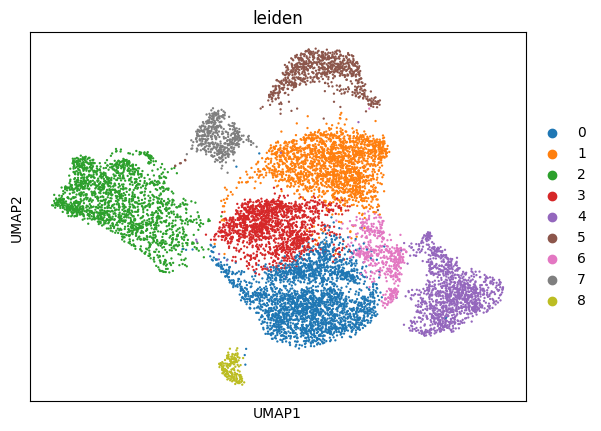

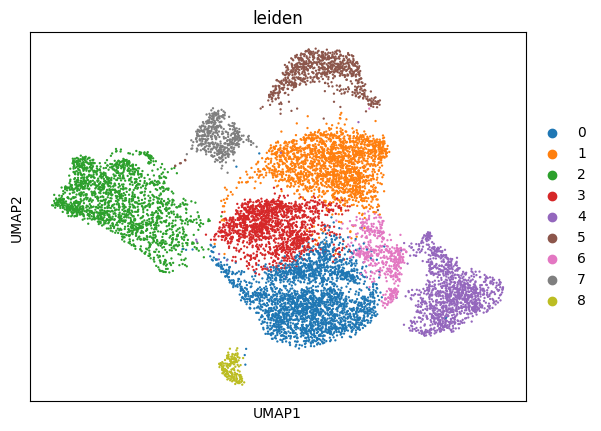

In [28]:
sc.tl.umap(adata_gene)
sc.pl.umap(adata_gene, color=['leiden'])
sc.pl.umap(adata_gene, color=['leiden'])

In [29]:
antigen_colors

{'A0301_KLGGALQAK_IE-1_CMV_binder': (0.0, 1.0, 0.0),
 'A1101_IVTDFSVIK_EBNA-3B_EBV_binder': (0.8057749562913745,
  0.0019373581817969665,
  0.9839661551449116),
 'A0201_GILGFVFTL_Flu-MP_Influenza_binder': (1.0, 0.5, 0.0),
 'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder': (0.011129059142101383,
  0.5668934727050611,
  0.8554267043895255),
 'B0801_RAKFKQLL_BZLF1_EBV_binder': (0.0, 0.0, 1.0),
 'A0201_ELAGIGILTV_MART-1_Cancer_binder': (0.5898679395592455,
  0.9413608427267085,
  0.40663993742850757),
 'A0201_LLDFVRFMGV_EBNA-3B_EBV_binder': (0.4768365108381304,
  0.3258418087835008,
  0.40916217272664346),
 'A0301_RLRAEAQVK_EMNA-3A_EBV_binder': (0.9814823899920717,
  0.02327445505371195,
  0.28148769164000687),
 'A0201_GLCTLVAML_BMLF1_EBV_binder': (0.7270566382153227,
  0.5543530293341455,
  0.9673438112809636),
 'unknown': (0.75, 0.75, 0.75)}

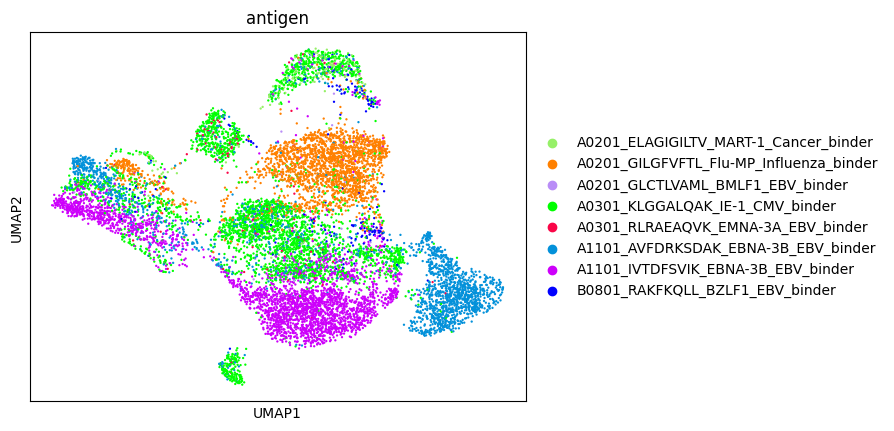

In [30]:
color_palette = [antigen_colors[cat] for cat in bind_list]
sc.pl.umap(
    adata_gene, 
    color=['antigen'], 
    palette=antigen_colors
)

In [31]:
normalized_mutual_info_score(
    adata_gene.obs['leiden'].astype('int').values,
    adata_gene.obs['peptide'].astype('category').cat.codes.values
)

0.40708125660053035

In [32]:
from sklearn.metrics.cluster import adjusted_rand_score
ari_score = adjusted_rand_score(adata_gene.obs['leiden'].astype('int').values, adata_gene.obs['peptide'].astype('category').cat.codes.values)
print(f"ARI Score: {ari_score}")

ARI Score: 0.3657969381274631


In [33]:
adjusted_rand_score(adata_gene.obs['cdr3_TRB'].astype('category').cat.codes.values, adata_gene.obs['peptide'].astype('category').cat.codes.values)
print(f"ARI Score: {ari_score}")

ARI Score: 0.3657969381274631


In [34]:
from sklearn.metrics.cluster import normalized_mutual_info_score, adjusted_rand_score
from tqdm import tqdm
adata_emb = ad.AnnData(all_embed)
adata_emb.obs = data_10X_dat
adata_emb = adata_emb[adata_emb.obs.antigen.isin(donor_1_peptides)]
# sc.pp.normalize_total(adata_emb, target_sum=1e4)
sc.tl.pca(adata_emb,svd_solver='arpack')
best_nmi = 0
best_resolution = 0
best_n_neighbors = 0
for npcs in tqdm([20,25, 30,35 ,40, 45]):
    for resolution in [ 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
        for n_neighbors in [5, 10, 15, 20, 25, 30]:
            sc.pp.neighbors(adata_emb, n_neighbors=n_neighbors, n_pcs=npcs)
            sc.tl.leiden(adata_emb, resolution=resolution)
            nmi_score = normalized_mutual_info_score(
                adata_emb.obs['leiden'].astype('int').values,
                adata_emb.obs['peptide'].astype('category').cat.codes.values
            )
            print(f"Resolution: {resolution}, N_neighbors: {n_neighbors}, NMI Score: {nmi_score}, PCs: {npcs}")
            if nmi_score > best_nmi:
                best_nmi = nmi_score
                best_resolution = resolution
                best_n_neighbors = n_neighbors
                best_npcs = npcs
print(f"Best NMI Score: {best_nmi} at Resolution: {best_resolution}, N_neighbors: {best_n_neighbors}, PCs: {best_npcs}")
# sc.pl.pca_variance_ratio(adata_emb, log=True)
# sc.pp.neighbors(adata_emb, n_neighbors=3, n_pcs=35)
# sc.tl.leiden(adata_emb, resolution=0.3)
# sc.tl.umap(adata_emb)


/home/phile/miniconda3/envs/integration/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/phile/miniconda3/envs/integration/lib/python3.9/site-packages/anndata/_core/anndata.py:796: ImplicitModificationWarning: Trying to modify index of attribute `.obs` of view, initializing view as actual.
  getattr(self, attr).index = value
/home/phile/miniconda3/envs/integration/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:317: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca
  0%|          | 0/6 [00:00<?, ?it/s]

Resolution: 0.3, N_neighbors: 5, NMI Score: 0.5698590095712848, PCs: 20
Resolution: 0.3, N_neighbors: 10, NMI Score: 0.5893795474933955, PCs: 20
Resolution: 0.3, N_neighbors: 15, NMI Score: 0.5940988462165907, PCs: 20
Resolution: 0.3, N_neighbors: 20, NMI Score: 0.5975593444093615, PCs: 20
Resolution: 0.3, N_neighbors: 25, NMI Score: 0.5969266157540462, PCs: 20
Resolution: 0.3, N_neighbors: 30, NMI Score: 0.5964481680814342, PCs: 20
Resolution: 0.4, N_neighbors: 5, NMI Score: 0.5646220980373795, PCs: 20
Resolution: 0.4, N_neighbors: 10, NMI Score: 0.5688894439437217, PCs: 20
Resolution: 0.4, N_neighbors: 15, NMI Score: 0.5757559064749116, PCs: 20
Resolution: 0.4, N_neighbors: 20, NMI Score: 0.5732270236327961, PCs: 20
Resolution: 0.4, N_neighbors: 25, NMI Score: 0.5739558549176188, PCs: 20
Resolution: 0.4, N_neighbors: 30, NMI Score: 0.5977659878451163, PCs: 20
Resolution: 0.5, N_neighbors: 5, NMI Score: 0.5287352447316171, PCs: 20
Resolution: 0.5, N_neighbors: 10, NMI Score: 0.5670399

 17%|█▋        | 1/6 [04:09<20:49, 249.95s/it]

Resolution: 0.9, N_neighbors: 30, NMI Score: 0.5166575949711442, PCs: 20
Resolution: 0.3, N_neighbors: 5, NMI Score: 0.5655687680671018, PCs: 25
Resolution: 0.3, N_neighbors: 10, NMI Score: 0.5869496807020809, PCs: 25
Resolution: 0.3, N_neighbors: 15, NMI Score: 0.5962400737021483, PCs: 25
Resolution: 0.3, N_neighbors: 20, NMI Score: 0.5963991590654832, PCs: 25
Resolution: 0.3, N_neighbors: 25, NMI Score: 0.5991896697039619, PCs: 25
Resolution: 0.3, N_neighbors: 30, NMI Score: 0.5958925403024145, PCs: 25
Resolution: 0.4, N_neighbors: 5, NMI Score: 0.5635636917788127, PCs: 25
Resolution: 0.4, N_neighbors: 10, NMI Score: 0.5683671941605334, PCs: 25
Resolution: 0.4, N_neighbors: 15, NMI Score: 0.5709247785946696, PCs: 25
Resolution: 0.4, N_neighbors: 20, NMI Score: 0.5698677215640812, PCs: 25
Resolution: 0.4, N_neighbors: 25, NMI Score: 0.5714028829395561, PCs: 25
Resolution: 0.4, N_neighbors: 30, NMI Score: 0.5933606138788239, PCs: 25
Resolution: 0.5, N_neighbors: 5, NMI Score: 0.5252756

 33%|███▎      | 2/6 [08:12<16:23, 245.83s/it]

...

Resolution: 0.9, N_neighbors: 30, NMI Score: 0.5330341245111764, PCs: 35
Resolution: 0.3, N_neighbors: 5, NMI Score: 0.5679335598228974, PCs: 40
Resolution: 0.3, N_neighbors: 10, NMI Score: 0.57262840739095, PCs: 40
Resolution: 0.3, N_neighbors: 15, NMI Score: 0.5929483806746918, PCs: 40
Resolution: 0.3, N_neighbors: 20, NMI Score: 0.592883405689825, PCs: 40
Resolution: 0.3, N_neighbors: 25, NMI Score: 0.5923366290330352, PCs: 40
Resolution: 0.3, N_neighbors: 30, NMI Score: 0.5870318508888788, PCs: 40
Resolution: 0.4, N_neighbors: 5, NMI Score: 0.5629183749148748, PCs: 40
Resolution: 0.4, N_neighbors: 10, NMI Score: 0.5637471345124822, PCs: 40
Resolution: 0.4, N_neighbors: 15, NMI Score: 0.567112421605946, PCs: 40
Resolution: 0.4, N_neighbors: 20, NMI Score: 0.5717599125717585, PCs: 40
Resolution: 0.4, N_neighbors: 25, NMI Score: 0.5692713341886857, PCs: 40
Resolution: 0.4, N_neighbors: 30, NMI Score: 0.5893760959620568, PCs: 40
Resolution: 0.5, N_neighbors: 5, NMI Score: 0.55758959391

 83%|████████▎ | 5/6 [21:04<04:15, 255.44s/it]

Resolution: 0.9, N_neighbors: 30, NMI Score: 0.5432974711796035, PCs: 40
Resolution: 0.3, N_neighbors: 5, NMI Score: 0.5674214160204858, PCs: 45
Resolution: 0.3, N_neighbors: 10, NMI Score: 0.5743189526020915, PCs: 45
Resolution: 0.3, N_neighbors: 15, NMI Score: 0.5762883610075704, PCs: 45
Resolution: 0.3, N_neighbors: 20, NMI Score: 0.5927642099110978, PCs: 45
Resolution: 0.3, N_neighbors: 25, NMI Score: 0.5948646271404118, PCs: 45
Resolution: 0.3, N_neighbors: 30, NMI Score: 0.5938576363864088, PCs: 45
Resolution: 0.4, N_neighbors: 5, NMI Score: 0.5528479168216001, PCs: 45
Resolution: 0.4, N_neighbors: 10, NMI Score: 0.5680235306226662, PCs: 45
Resolution: 0.4, N_neighbors: 15, NMI Score: 0.5699471390779561, PCs: 45
Resolution: 0.4, N_neighbors: 20, NMI Score: 0.5862201085861358, PCs: 45
Resolution: 0.4, N_neighbors: 25, NMI Score: 0.5841444961427443, PCs: 45
Resolution: 0.4, N_neighbors: 30, NMI Score: 0.5894829073141595, PCs: 45
Resolution: 0.5, N_neighbors: 5, NMI Score: 0.5353484

100%|██████████| 6/6 [25:24<00:00, 254.08s/it]

Resolution: 0.9, N_neighbors: 30, NMI Score: 0.5370998251258366, PCs: 45
Best NMI Score: 0.5991896697039619 at Resolution: 0.3, N_neighbors: 25, PCs: 25


In [35]:
adata_emb.obs

,v_gene_TRA,v_gene_TRB,d_gene_TRA,d_gene_TRB,j_gene_TRA,j_gene_TRB,c_gene_TRA,c_gene_TRB,cdr3_TRA,cdr3_TRB,...,NR(B0801)_AAKGRGAAL_NC,antigen,peptide,orig_ix,n_counts,log_counts,n_genes,mt_fraction,used_ix,leiden
barcode,,,,,,,,,,,,,,,,,,,,,
AGGGTGAGTATTACCG-18,TRAV19,TRBV20-1,None,TRBD2,TRAJ40,TRBJ2-3,TRAC,TRBC2,CALSEASGTYKYIF,CSAPSGEGRDTQYF,...,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,0,5478.0,3.738622,1830,0.058050,0,6
CTGCGGATCGACAGCC-31,TRAV14DV4,TRBV4-3,None,TRBD1,TRAJ28,TRBJ1-2,TRAC,TRBC1,CAMREPYSGAGSYQLTF,CASSQDRQGISIGYTF,...,1.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,6,2995.0,3.476397,1527,0.064775,5,4
GAGCAGAAGCGTGAGT-37,TRAV36DV7,TRBV9,None,TRBD1,TRAJ54,TRBJ1-1,TRAC,TRBC1,CAHLQGAQKLVF,CASSEGDRVTEAFF,...,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,10,3915.0,3.592732,1624,0.028097,9,5
TGAAAGATCGAGAACG-32,TRAV16,TRBV29-1,None,TRBD1,TRAJ53,TRBJ2-2,TRAC,TRBC2,CALSGGSNYKLTF,CSDRGGTGELFF,...,0.0,A0201_GILGFVFTL_Flu-MP_Influenza_binder,GILGFVFTL,12,8505.0,3.929674,2151,0.067372,11,1
CGATGTACAGTTCATG-28,TRAV16,TRBV11-2,None,TRBD1,TRAJ49,TRBJ1-2,TRAC,TRBC1,CAPGNQFYF,CASSWGGGSHYGYTF,...,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,13,1827.0,3.261739,1015,0.121511,12,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CAGCTGGAGACAATAC-33,TRAV12-1,TRBV9,None,TRBD2,TRAJ16,TRBJ2-1,TRAC,TRBC2,CVVKGLTPFRDGQKLLF,CASSSPSSSYNEQFF,...,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,39674,3273.0,3.514946,1639,0.070883,35496,3
CCTTACGTCGGACAAG-19,TRAV19,TRBV30,None,TRBD1,TRAJ17,TRBJ1-6,TRAC,TRBC1,CALKLIKAAGNKLTF,CAWTGTGKIGWDSPLHF,...,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,39676,4271.0,3.630530,1693,0.070241,35497,4
GTGAAGGGTACCGTAT-36,TRAV12-3,TRBV20-1,None,TRBD1,TRAJ32,TRBJ2-7,TRAC,TRBC2,CAMNPAWGGATNKLIF,CSASPGDYEQYF,...,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,39691,2345.0,3.370143,1146,0.121109,35510,6


In [36]:
adjusted_rand_score(adata_emb.obs['leiden'].astype('int').values, adata_emb.obs['peptide'].astype('category').cat.codes.values)

0.5139809631119449

NMI Score: 0.5991896697039619


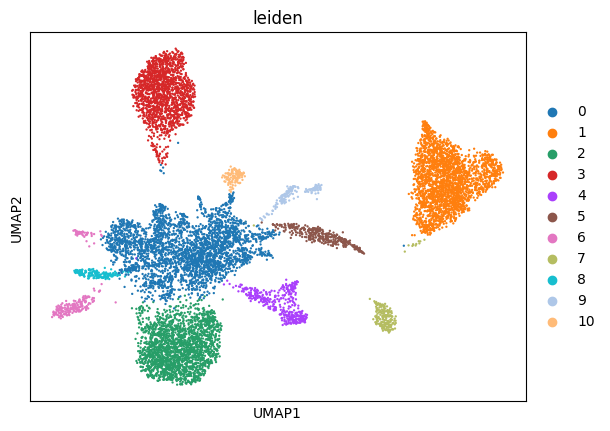

In [37]:
sc.pp.neighbors(adata_emb, n_neighbors = best_n_neighbors, n_pcs=best_npcs)
sc.tl.leiden(adata_emb, resolution=best_resolution)
nmi_score = normalized_mutual_info_score(adata_emb.obs['leiden'].astype('int').values, adata_emb.obs['peptide'].astype('category').cat.codes.values)
print(f"NMI Score: {nmi_score}")
sc.tl.umap(adata_emb)
sc.pl.umap(adata_emb, color=['leiden'])

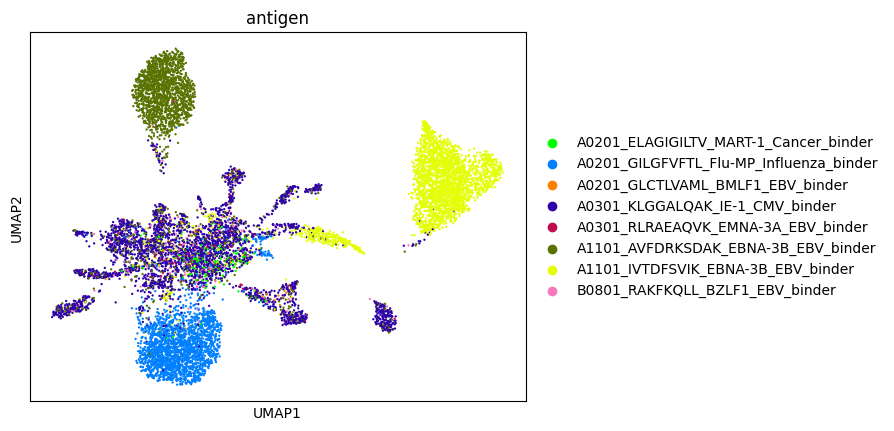

In [38]:
antigen_colors = {'A0201_ELAGIGILTV_MART-1_Cancer_binder': (0.0, 1.0, 0.0),
 'A0201_FLYALALLL_LMP2A_EBV_binder': (1.0, 0.0, 1.0),
 'A0201_GILGFVFTL_Flu-MP_Influenza_binder': (0.0, 0.5, 1.0),
 'A0201_GLCTLVAML_BMLF1_EBV_binder': (1.0, 0.5, 0.0),
 'A0201_LLDFVRFMGV_EBNA-3B_EBV_binder': (0.5, 0.75, 0.5),
 'A0301_KLGGALQAK_IE-1_CMV_binder': (0.1793537164011899,
  0.0033355078444660125,
  0.6620747897259032),
 'A0301_RLRAEAQVK_EMNA-3A_EBV_binder': (0.73968214343272,
  0.05891730149257346,
  0.3146809676494471),
 'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder': (0.349066435944829,
  0.4503226204406996,
  0.013129173322001919),
 'A1101_IVTDFSVIK_EBNA-3B_EBV_binder': (0.8921739233639615,
  0.9978312313940568,
  0.032996100920834937),
 'B0801_FLRGRAYGL_EBNA-3A_EBV_binder': (0.0, 1.0, 1.0),
 'B0801_RAKFKQLL_BZLF1_EBV_binder': (0.9677051631643115,
  0.47190225320587564,
  0.729773079807986),
 'unknown': (0.71, 0.71, 0.71)}
sc.pl.umap(
    adata_emb, 
    color=['antigen'], 
    palette=antigen_colors
)

In [39]:
# adata_emb.obs['antigen_color'] = [antigen_colors[x] for x in adata_emb.obs['antigen'].values]
# adata_emb.obs

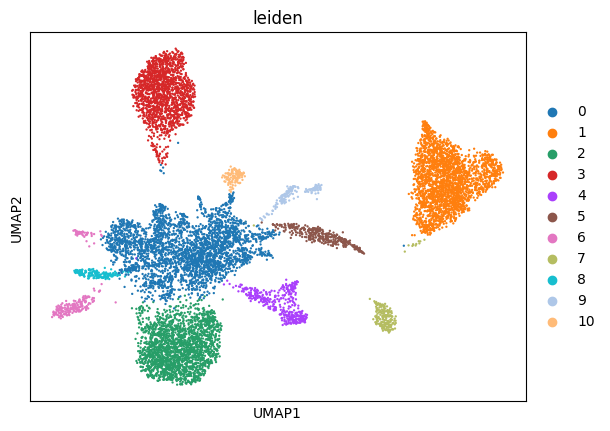

In [40]:
sc.pl.umap(adata_emb, color=['leiden'])

In [41]:
adata_emb.obs['antigen'].value_counts()

antigen
A0301_KLGGALQAK_IE-1_CMV_binder            3138
A1101_IVTDFSVIK_EBNA-3B_EBV_binder         2925
A0201_GILGFVFTL_Flu-MP_Influenza_binder    2155
A1101_AVFDRKSDAK_EBNA-3B_EBV_binder        2080
B0801_RAKFKQLL_BZLF1_EBV_binder             194
A0201_ELAGIGILTV_MART-1_Cancer_binder       193
A0301_RLRAEAQVK_EMNA-3A_EBV_binder          113
A0201_GLCTLVAML_BMLF1_EBV_binder             34
Name: count, dtype: int64

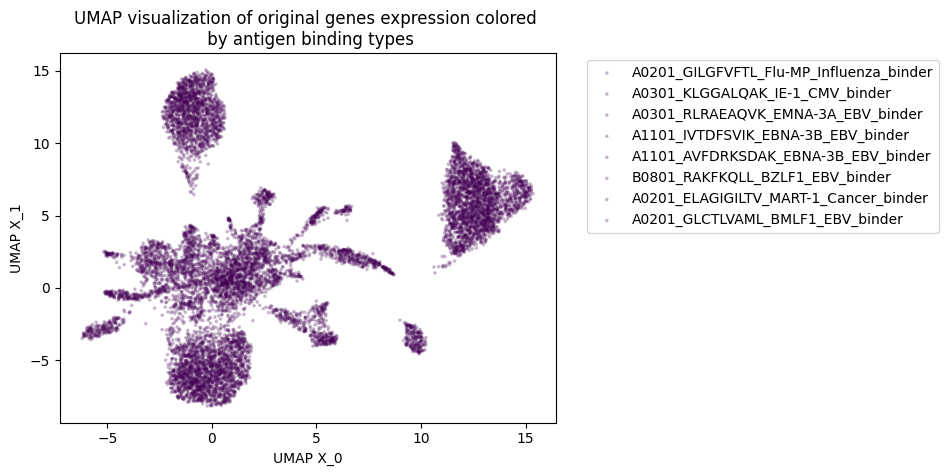

In [42]:
uniq = list(set(adata_emb.obs['antigen'].values))
alpha = 0.2

for i in range(len(uniq)):
    indx = adata_emb.obs['antigen'] == uniq[i]
    plt.scatter(adata_emb.obsm['X_umap'][list(indx),0], adata_emb.obsm['X_umap'][list(indx),1], s=3, c=adata_emb.obs['antigen'].astype('category').cat.codes.values[indx],label=uniq[i], alpha=alpha)

plt.xlabel('UMAP X_0')
plt.ylabel('UMAP X_1')
plt.title('UMAP visualization of original genes expression colored \n by antigen binding types')
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1.0))
plt.show()

In [43]:
adata_emb.obs

,v_gene_TRA,v_gene_TRB,d_gene_TRA,d_gene_TRB,j_gene_TRA,j_gene_TRB,c_gene_TRA,c_gene_TRB,cdr3_TRA,cdr3_TRB,...,NR(B0801)_AAKGRGAAL_NC,antigen,peptide,orig_ix,n_counts,log_counts,n_genes,mt_fraction,used_ix,leiden
barcode,,,,,,,,,,,,,,,,,,,,,
AGGGTGAGTATTACCG-18,TRAV19,TRBV20-1,None,TRBD2,TRAJ40,TRBJ2-3,TRAC,TRBC2,CALSEASGTYKYIF,CSAPSGEGRDTQYF,...,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,0,5478.0,3.738622,1830,0.058050,0,4
CTGCGGATCGACAGCC-31,TRAV14DV4,TRBV4-3,None,TRBD1,TRAJ28,TRBJ1-2,TRAC,TRBC1,CAMREPYSGAGSYQLTF,CASSQDRQGISIGYTF,...,1.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,6,2995.0,3.476397,1527,0.064775,5,0
GAGCAGAAGCGTGAGT-37,TRAV36DV7,TRBV9,None,TRBD1,TRAJ54,TRBJ1-1,TRAC,TRBC1,CAHLQGAQKLVF,CASSEGDRVTEAFF,...,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,10,3915.0,3.592732,1624,0.028097,9,5
TGAAAGATCGAGAACG-32,TRAV16,TRBV29-1,None,TRBD1,TRAJ53,TRBJ2-2,TRAC,TRBC2,CALSGGSNYKLTF,CSDRGGTGELFF,...,0.0,A0201_GILGFVFTL_Flu-MP_Influenza_binder,GILGFVFTL,12,8505.0,3.929674,2151,0.067372,11,2
CGATGTACAGTTCATG-28,TRAV16,TRBV11-2,None,TRBD1,TRAJ49,TRBJ1-2,TRAC,TRBC1,CAPGNQFYF,CASSWGGGSHYGYTF,...,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,13,1827.0,3.261739,1015,0.121511,12,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CAGCTGGAGACAATAC-33,TRAV12-1,TRBV9,None,TRBD2,TRAJ16,TRBJ2-1,TRAC,TRBC2,CVVKGLTPFRDGQKLLF,CASSSPSSSYNEQFF,...,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,39674,3273.0,3.514946,1639,0.070883,35496,0
CCTTACGTCGGACAAG-19,TRAV19,TRBV30,None,TRBD1,TRAJ17,TRBJ1-6,TRAC,TRBC1,CALKLIKAAGNKLTF,CAWTGTGKIGWDSPLHF,...,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,39676,4271.0,3.630530,1693,0.070241,35497,0
GTGAAGGGTACCGTAT-36,TRAV12-3,TRBV20-1,None,TRBD1,TRAJ32,TRBJ2-7,TRAC,TRBC2,CAMNPAWGGATNKLIF,CSASPGDYEQYF,...,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,39691,2345.0,3.370143,1146,0.121109,35510,4


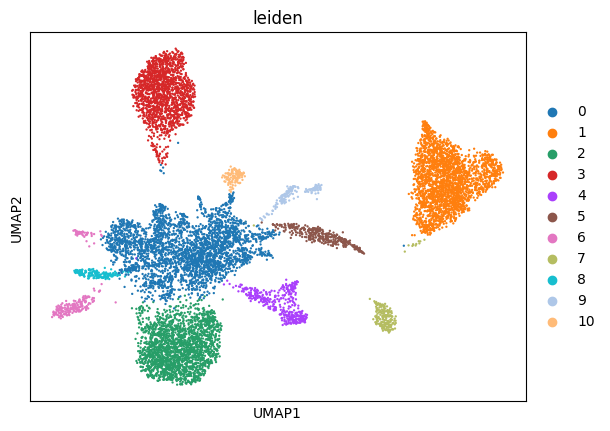

In [44]:
sc.pl.umap(adata_emb, color=['leiden'])

In [45]:
# sc.pl.umap(adata_emb, color=['IR_VDJ_1_junction_aa'])

In [46]:
# data_10X_dat[['cdr3b','Peptide_sequence']].groupby('cdr3b').value_counts().sort_values(ascending=False)

In [47]:
# data_10X_dat[data_10X_dat.cdr3b == "CASSLGFPNQPQHF"]        

In [48]:
# data_10X_dat[data_10X_dat.Peptide_sequence == "TTDPSFLGRY"].groupby('cdr3b')[['cdr3b','Peptide_sequence']].value_counts().sort_values(ascending=False)        

In [49]:
# data_10X_dat[data_10X_dat.Peptide_sequence == "LTDEMIAQY"].groupby('cdr3b')[['cdr3b','Peptide_sequence']].value_counts()        

In [50]:
from sklearn.metrics.cluster import normalized_mutual_info_score

In [51]:
nmi_score = normalized_mutual_info_score(adata_emb.obs['leiden'].astype('int').values, adata_emb.obs['peptide'].astype('category').cat.codes.values)
print(f"NMI Score: {nmi_score}")

NMI Score: 0.5991896697039619


In [52]:
nmi_score = normalized_mutual_info_score(adata_emb.obs['cdr3_TRB'].astype('category').cat.codes.values, adata_emb.obs['peptide'].astype('category').cat.codes.values)
print(f"NMI Score: {nmi_score}")

NMI Score: 0.4478530132131785


In [53]:
nmi_score = normalized_mutual_info_score(adata_emb.obs['cdr3_TRA'].astype('category').cat.codes.values, adata_emb.obs['peptide'].astype('category').cat.codes.values)
print(f"NMI Score: {nmi_score}")

NMI Score: 0.42991339611784485


In [54]:
ari_score = adjusted_rand_score(adata_emb.obs['leiden'].astype('int').values, adata_emb.obs['peptide'].astype('category').cat.codes.values)
print(f"ARI Score: {ari_score}")

ARI Score: 0.5847606628642472


In [55]:
adjusted_rand_score(adata_emb.obs['cdr3_TRB'].astype('category').cat.codes.values, adata_emb.obs['peptide'].astype('category').cat.codes.values)

0.41865136332624187

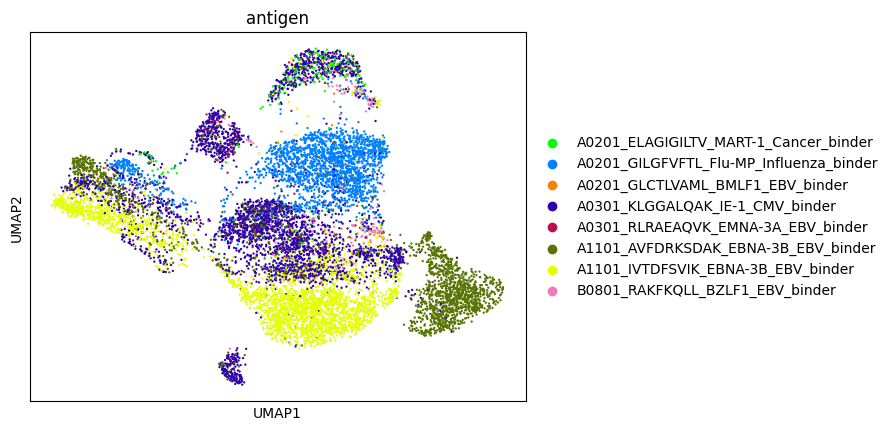

In [56]:
sc.pl.umap(
    adata_gene, 
    color=['antigen'], 
    palette=antigen_colors
)